In [1]:
%load_ext autoreload
%autoreload 2

# python
import os
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
# import pandas as pd
import math
import sys
sys.path.append("../")
import socket
import glob
import h5py

# # get hostname
# if "NERSC_HOST" in os.environ:
#     hostname = "perlmutter.nersc.gov"
# else:
#     hostname = socket.gethostname()
# print(hostname)

# custom
import Utils as ut
# from Utils import loadALEPH2004Result, loadWeights, ensembleWeights, calc_hist, plotThrust, ensemblePredsThenGetWeight
# import dataloader

In [54]:
# OF results
OF_file = "./theoryComparison_NewNeutralSys/unfold_thrust_ee_ZPole_ALEPH.h5"
with h5py.File(OF_file, "r") as f:
    OF = {key: f[key][()] for key in f.keys()}

# ibu tau results
ibu_results = {}
# tau
IBU_tau_file = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-f8528cb9/ibu_results.npz"
with np.load(IBU_tau_file) as f:
    ibu_results["tau"] = {key: f[key] for key in f.keys()}

# Now both files are closed and data is stored in memory
print("OF keys:", list(OF.keys()))
print("IBU keys:", list(ibu_results["tau"].keys()))

OF keys: ['aleph_lep1_data', 'archived_pythia61_gen', 'archived_pythia61_reco', 'bootstrap_weights_data', 'bootstrap_weights_mc', 'ensemble_weights', 'herwig715', 'pythia8230_gen', 'pythia8230_gen_hadoff', 'sherpa226', 'systematic_weights', 'systematic_weights_order', 'theory_weights', 'theory_weights_order']
IBU keys: ['nominal', 'total_stat', 'bootstrapmc', 'bootstrapdata', 'exp_syst_names', 'exp_syst', 'total_exp_syst', 'th_syst_names', 'th_syst', 'total_th_syst', 'total_uncert']


In [50]:
# decode bytes from OF result
systematic_weights_order = [i.decode("utf-8") for i in OF["systematic_weights_order"]]
theory_weights_order = [i.decode("utf-8") for i in OF["theory_weights_order"]]

In [51]:
# load aleph result
aleph = ut.loadALEPH2004Result(hepData = "/home/badea/e+e-/aleph/UnfoldThrustResults/HEPData-ins636645-v1-Table_54.csv")

THRUST,THRUST LOW,THRUST HIGH,(1/SIG)*D(SIG)/DTHRUST,stat +,stat -,sys_1 +,sys_1 -,sys_2 +,sys_2 -


/home/badea/e+e-/aleph/unfold-ee-logtau/Plotting/Utils.py:161: RuntimeWarning: divide by zero encountered in log
  aleph_log_bins = np.log(aleph_bins)


In [52]:
# theory comparison
tRange = np.linspace(0.055, 0.42, 100)
resummedMinO3_default = [6.940832825041935, 6.341458718467728, 5.816399913930998, 5.353937628339428, 4.943781315946968, 4.577963625641645, 4.250115226730342, 3.9550402784590397, 3.6884405308849284, 3.4467227209500924, 3.2268575262075525, 3.0262728671558206, 2.8426562916368834, 2.6740110713881116, 2.518736873117851, 2.375444048479781, 2.2429343968922226, 2.1201718701481544, 2.006184222855005, 1.9001168149963965, 1.8012590329462927, 1.7089966381696315, 1.6227663059067905, 1.542047233700446, 1.4663689897429137, 1.3953151940063726, 1.3284772078230278, 1.2655466277267675, 1.206229908489983, 1.150282019146988, 1.0974522894988328, 1.0474301186671766, 1.0000337183704895, 0.9551259409664757, 0.9125557306914507, 0.8721896367586247, 0.8338822788529042, 0.7973986952689529, 0.762666771414239, 0.7295745613809539, 0.6980139895413014, 0.6679055510883084, 0.6391478934639551, 0.6116612646460442, 0.5853755203633674, 0.560249169513277, 0.5362228080228093, 0.5131708512083434, 0.4910464317297443, 0.4698438613777879, 0.44945112488258526, 0.42981235211359053, 0.41092163926791775, 0.3927454646190022, 0.3752214364516214, 0.358172384121723, 0.34173823345162324, 0.3258187574812346, 0.31030829114705616, 0.29529982212036365, 0.2807521646525358, 0.26659469955881543, 0.252820962970969, 0.23944223811661522, 0.2264056149787944, 0.21366294249218598, 0.2012020314672536, 0.18900945060383206, 0.1770447078157762, 0.1652876449041089, 0.15370802350727455, 0.14225040354229274, 0.13094229972219262, 0.11982367988663567, 0.10886393458344704, 0.0980800245748266, 0.08754609001354305, 0.07715890255407273, 0.06641702481475538, 0.05591039528952053, 0.04574365340684547, 0.03554880195425263, 0.02709038794773503, 0.020664847767831312, 0.01603269234537052, 0.012670077008700565, 0.010094823769173419, 0.008049075951038058, 0.006412869731300771, 0.005107067142336883, 0.004062614906341569, 0.003220681249810244, 0.002537119482303891, 0.0019814895576650998, 0.0015306844852936803, 0.001167270577710536, 0.0008765597018718309, 0.0006463431899502485, 0.0004655099006142297, 0.0003243598764052057]
resummedMaxO3_default = [7.439277505874193, 6.777482375753597, 6.20208263695515, 5.695604310838082, 5.246901154852542, 4.847529681188686, 4.491486810119176, 4.171301955023966, 3.883016574406612, 3.6225984940222213, 3.386474869327102, 3.1716325183161467, 2.9755215759094704, 2.7959731752457846, 2.631136568077504, 2.479448690016976, 2.3395053606069918, 2.210059731401582, 2.0900723022377896, 1.978660098855796, 1.8750328096655524, 1.7784234351333355, 1.6881620104335076, 1.603698951725191, 1.524548429658947, 1.4502776965331996, 1.3805000866792205, 1.3148674211013922, 1.253057182930283, 1.1947654903500475, 1.139715036489212, 1.087673723027872, 1.038452139147989, 0.9918761579954513, 0.9477562949407351, 0.9058947359880685, 0.8661147006694736, 0.8282793947574758, 0.7922774431946611, 0.7579968281588542, 0.7253153202651013, 0.694217745027458, 0.6646012633360976, 0.6363185027759034, 0.6093018230364992, 0.5834121898421329, 0.5585949634989424, 0.534837420956634, 0.5121331744918806, 0.4904140801727576, 0.46951011888132066, 0.4494111405545602, 0.4300780418448455, 0.41145622056726944, 0.3934692226373979, 0.37609209438708846, 0.35934331682997955, 0.343140297586253, 0.3274274743528359, 0.3122220643396108, 0.2974981152303112, 0.2831699076107105, 0.2691661231622857, 0.2555087785780243, 0.24216523648529592, 0.22908806361744505, 0.21626420124068446, 0.20369177265766855, 0.1913371332258452, 0.17916696029034307, 0.16716853170540172, 0.15529800201197325, 0.14355134080809673, 0.13198175330524256, 0.12058730454475043, 0.10934755921317851, 0.09831047845587378, 0.08748724536205267, 0.07679663290618462, 0.06608521952015903, 0.055274971840566005, 0.047223568230775566, 0.04150193289054424, 0.03439494693931753, 0.027578113477525725, 0.021952120271982636, 0.017576855101851398, 0.014217848954564268, 0.011578730104341026, 0.009429587134422995, 0.007647002380348997, 0.006163658170169567, 0.004934084155624209, 0.003915264099093843, 0.0030712664883325506, 0.0023736323575842713, 0.001801218681628827, 0.0013372067033856276, 0.0009685403436023666, 0.0006837497071533714]
resummedAverO3_default = (np.array(resummedMinO3_default) + np.array(resummedMaxO3_default))/2
resummedO3_as118O103 = [7.673494783048797, 7.005351982696255, 6.419216965609669, 5.901951378004811, 5.443653816734281, 5.03709140743407, 4.674009216272107, 4.347915246142539, 4.053667098402354, 3.7870837508790753, 3.5447037770107515, 3.323623367254467, 3.1213816409156783, 2.935876044379987, 2.765297512997027, 2.6080908656704818, 2.462858890064166, 2.3282284872404353, 2.2031430658864615, 2.086729767578329, 1.9782374854511475, 1.876980265498667, 1.7823249015341527, 1.693699969652766, 1.6106000763422448, 1.532577043408489, 1.4592304044652917, 1.3902012911818813, 1.3251653141888744, 1.2638198809332697, 1.2058778422233354, 1.1510762218369774, 1.0991960091930248, 1.0500604231065898, 1.0035076510138674, 0.9593584096357098, 0.9174214530254511, 0.87752334643979, 0.8395308470545575, 0.8033382847646504, 0.7688408754855378, 0.7359214912679546, 0.704469047275998, 0.6744160712521283, 0.6457119728503266, 0.6182571492399958, 0.5919136966769117, 0.5666810774041081, 0.5424925414527484, 0.5192237153431668, 0.49685154228713757, 0.4753545018388183, 0.4546819512313282, 0.43476259280165774, 0.41550841415855666, 0.39690483082211164, 0.3789380689677315, 0.3615036553853143, 0.34458916888855373, 0.32820939671704125, 0.3123130255226704, 0.2968290691111097, 0.2817616413963823, 0.2671176899101758, 0.25283756278842656, 0.23887546555133254, 0.22522231772618925, 0.21186132053498244, 0.19874038850248757, 0.18583159949999106, 0.1731040331282265, 0.16050577827911533, 0.14807348794754036, 0.1358481120666816, 0.12380139073225244, 0.1119728484467996, 0.10044729763276813, 0.08912640800963065, 0.0777642765243639, 0.06613539961828382, 0.05587037171802543, 0.047721960018853975, 0.03825363461653174, 0.029601070342029908, 0.02271801210262943, 0.017595515695005937, 0.013845158439873868, 0.011004844036414678, 0.008756076462732578, 0.006945035686488846, 0.0054897045767379315, 0.00432798284990429, 0.0034014705572701968, 0.0026634412433433584, 0.0020797598257079443, 0.0016147360577614598, 0.0012387459139547698, 0.0009367561184395365, 0.0006964270214822246, 0.0005070858958379164]
resummedO3_as114O101 = [6.4031277964680084, 5.864602877080021, 5.3900625277212715, 4.970116929740449, 4.597850218122002, 4.265655874151077, 3.9675253577838316, 3.6986838560460376, 3.4552485866077465, 3.234009110883498, 3.0322771878853048, 2.8477792514293916, 2.6785766283053474, 2.5230053409216087, 2.3796304653388933, 2.247213893255363, 2.124441397669389, 2.010354560796784, 1.9041890343895522, 1.8052659113499785, 1.712941891830763, 1.6266278807772634, 1.5458008062321216, 1.4700048914497705, 1.3988335580967186, 1.3319225804301185, 1.2689459700480503, 1.2096087550957515, 1.1536298236823066, 1.1007409414800673, 1.0507008942498788, 1.0033248249298106, 0.9584632808492164, 0.915968551309193, 0.8756551461715503, 0.8373368522972494, 0.8008596631204448, 0.7661205713411235, 0.7330307725101276, 0.7014879050768472, 0.6713728853589777, 0.6425814401260507, 0.615083284087138, 0.5888304820954355, 0.5637053920036663, 0.5395284228487248, 0.516444567490918, 0.4942817510027679, 0.47291040310365307, 0.4523948755434509, 0.4326834145222529, 0.4137183355132205, 0.3954237446470024, 0.3777020125671695, 0.3606275751029187, 0.34413750871223103, 0.32806723649868785, 0.31250815847803076, 0.2974575632661042, 0.2828220239471098, 0.2685269038562711, 0.2546460994949419, 0.24116167280981066, 0.22796978726782766, 0.21505668529467128, 0.20243426383021051, 0.19007344114947328, 0.1778959213661731, 0.16591277633718046, 0.15407618020391098, 0.14231782698634274, 0.1307650855001813, 0.11941935992543169, 0.10820195120508777, 0.09719698718380518, 0.08655490519506502, 0.07599912369910448, 0.06522361824036334, 0.05410668423993751, 0.04543897831068383, 0.03811268059229785, 0.029057591462203367, 0.02218686435779965, 0.017061002096139862, 0.013399847689925217, 0.010697180337890489, 0.008546766444865442, 0.0067951037402095875, 0.005377921490672875, 0.004244215924598972, 0.0033396264426932038, 0.002615271549580146, 0.002035469580861753, 0.0015780084317612362, 0.001214382542232023, 0.0009221471703681753, 0.0006880378370046194, 0.0005036406811184299, 0.000359576294177678, 0.0002473631259093354]
resummedMinO3_default = np.array(resummedMinO3_default)
resummedMaxO3_default = np.array(resummedMaxO3_default)
resummedO3_as118O103 = np.array(resummedO3_as118O103)
resummedO3_as114O101 = np.array(resummedO3_as114O101)

In [53]:
# PAPER BINNING
customBins = list(np.linspace(aleph["log_bins_min"], -5, 3, endpoint=False))
customBins += list(np.linspace(-5, math.log(0.06), 20, endpoint=False))
customBins += list(np.linspace(math.log(0.06), math.log(0.23), 34, endpoint=False)) # 17
customBins += list(np.linspace(math.log(0.23), math.log(0.42), 40, endpoint=True)) # 20
customBins = np.array(customBins)
customBinsTau = np.exp(customBins)

# theory values are bin centers
bin_width = tRange[1] - tRange[0]
edges = np.zeros(len(tRange) + 1)
edges[1:-1] = (tRange[:-1] + tRange[1:]) / 2
edges[0] = tRange[0] - bin_width/2      # first edge
edges[-1] = tRange[-1] + bin_width/2    # last edge
customBinsTau = edges
    
# plotting configuration
conf = {
    "logtau" : {
        "aleph" : {
            "x" : aleph["aleph_log_midbins"], 
            "y": aleph["aleph_log_thrust"], 
            "xerr": aleph["aleph_log_binwidths"]/2, 
            "yerr": aleph["aleph_log_thrust_errs"], 
            "bins" : aleph["aleph_log_bins"],
        },
        "ax1_ylabel" : r"1/$\sigma$ d$\sigma$/d$\log(\tau)$",
        "ax1_yscale" : "log",
        "ax2_xscale" : "linear",
        "ax1_ylim" : [0.2*10**-5, 10**0],
        "ax2_xlabel" : r"$\log(\tau)$", # "log(1-T)",
        "ax2_ylim" : [0.01, 1.99],
        "bins" : customBins,
        "legend" : "lower right",
        "legend_bbox" : (0.98, 0.0)
    },
    "tau" : {
        "aleph" : {
            "x" : aleph["aleph_midbins"], 
            "y": aleph["aleph_thrust"], 
            "xerr": aleph["aleph_binwidths"]/2, 
            "yerr": aleph["aleph_thrust_errs"], 
            "bins" : aleph["aleph_bins"]
        },
        "ax1_ylabel" : r"1/$\sigma$ d$\sigma$/d$(\tau)$",
        "ax1_yscale" : "log",
        "ax2_xscale" : "linear",
        "ax1_ylim" : [0.3*10**-3, 4*10**1],
        "ax2_xlabel" : r"$\tau$",
        "ax2_ylim" : [0.68, 1.32],
        "bins" : customBinsTau, # np.exp(customBins),
        "legend" : "lower left",
        "legend_bbox" : (0.05, 0.0)
    },
}    

In [32]:
def toHistVersion(data, name):
    # assume data = np.log(tau)
    if name == "tau":
        return np.exp(data)
    return data
    
# make histograms
plots = {}
for key, val in conf.items():
    plots[key] = {}
    for binType in ["nominal", "aleph"]:
        bins = val["bins"] if binType == "nominal" else val["aleph"]["bins"]
        
        # data histograms
        plots[key][f"data_{binType}"] = ut.calc_hist(toHistVersion(OF["aleph_lep1_data"], key), bins=bins, density=True) # = counts_data, errors_data, bin_edges
        
        # mc reco histograms
        plots[key][f"mc_reco_{binType}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_reco"], key), bins=bins, density=True)
        
        # gen before histograms
        plots[key][f"mc_genBefore_{binType}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True)
        
        # theory comparisons
        for theory in ["pythia8230_gen", "pythia8230_gen_hadoff", "herwig715", "sherpa226"]:
            plots[key][f"{theory}_{binType}"] = ut.calc_hist(toHistVersion(OF[theory], key), bins=bins, density=True)
            
        for iW, weights in enumerate(np.squeeze(OF["ensemble_weights"], axis=0)):
            plots[key][f"unifold_{binType}_ensemble{iW}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True, weights=weights.flatten())
        
        for iW, weights in enumerate(OF["systematic_weights"]):
            plots[key][f"unifold_{binType}_systematic{iW}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True, weights=weights.flatten())
        
        for iW, weights in enumerate(OF["theory_weights"]):
            plots[key][f"unifold_{binType}_theory{iW}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True, weights=weights.flatten())
        
        for iW, weights in enumerate(np.squeeze(OF["bootstrap_weights_data"], axis=0)):
            plots[key][f"unifold_{binType}_bootstrapData{iW}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True, weights=weights.flatten())
        
        for iW, weights in enumerate(np.squeeze(OF["bootstrap_weights_mc"], axis=0)):
            plots[key][f"unifold_{binType}_bootstrapMC{iW}"] = ut.calc_hist(toHistVersion(OF["archived_pythia61_gen"], key), bins=bins, density=True, weights=weights.flatten())

In [39]:
skipNoNeutrals = True

errors = {}
for key, val in conf.items():
    errors[key] = {}
    for binType in ["nominal", "aleph"]:
        
        # bins
        bins = val["bins"] if binType == "nominal" else val["aleph"]["bins"]
        binwidths = bins[1:] - bins[:-1]
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # pick up nominal
        nominal = plots[key][f"unifold_{binType}_ensemble0"]
        systList = [
            # ["ensemble", 0], #ensemble_weights.shape[1]],
            ["systematic", OF["systematic_weights"].shape[0]],
            ["theory", OF["theory_weights"].shape[0]]
        ]

        # define lists for systematic errors and theory errors
        systematic_err = []
        theory_err = []
        theory_mask = []
        nes = {}
        for systType, iWRange in systList:
            for iW in range(iWRange):
                if systType == "systematic":
                    
                    if skipNoNeutrals and systematic_weights_order[iW] == 'no_neutrals':
                        print("Skipping no neutral systematic.")
                        continue
                    
                    # max value for nes_up and nes_down
                    if systematic_weights_order[iW] in ["nes_up", "nes_down"]:
                        print("Handling NES:", systematic_weights_order[iW])
                        nes[systematic_weights_order[iW]] = np.abs(nominal[0] - plots[key][f"unifold_{binType}_{systType}{iW}"][0])
                        continue

                    # compute
                    systematic_err.append(nominal[0] - plots[key][f"unifold_{binType}_{systType}{iW}"][0])
                
                if systType == "theory":
                    theory_err.append(nominal[0] - plots[key][f"unifold_{binType}_{systType}{iW}"][0])
                    theory_mask.append(ut.mc_bin_quality(
                        data_counts = nominal[0], # nominal result counts
                        data_err = nominal[1], # nominal result stat errors
                        mc_counts = plots[key][f"unifold_{binType}_{systType}{iW}"][0], # theory variation counts
                        mc_err = plots[key][f"unifold_{binType}_{systType}{iW}"][1], # theory variation stat error
                        rel_mc_unc_max = 15,
                        pull_abs_max = 2,
                    ))

        systematic_err_order = ["NTPC", "Track pT", "Charged Energy", "Thrust w/o Neutrals", "Thrust w/ MissP"]
        if skipNoNeutrals:
            systematic_err_order = ["NTPC", "Track pT", "Charged Energy", "Thrust w/ MissP", 'ner', 'nes']
            nes = np.maximum(nes["nes_up"], nes["nes_down"])
            systematic_err.append(nes)
            
        # compute totals
        total_exp_systematic_err = np.sqrt(np.sum(np.stack(systematic_err,axis=1)**2, axis=1)) # take the sqrt(sum in quadrature)
        
        # compute total theory uncertainty
        theory_err = np.stack(theory_err, axis=1)
        theory_mask = np.stack(theory_mask, axis=1)
        total_theory_err = np.nanmax(
            np.where(theory_mask, np.abs(theory_err), np.nan),
            axis=1
        )
        # Find rows where total_theory_err is NaN
        nan_rows = np.isnan(total_theory_err)
        # For those rows, take the minimum (ignoring NaN if present)
        total_theory_err[nan_rows] = np.nanmin(np.abs(theory_err[nan_rows]), axis=1)
        
        # get the ensemble uncertainty
        ensemble_err = []
        for iW in range(1, OF["ensemble_weights"].shape[1]): # don't include the nominal setting
            ensemble_err.append(plots[key][f"unifold_{binType}_ensemble{iW}"][0])
        ensemble_err = np.array(ensemble_err)
        total_ensemble_err = np.std(ensemble_err, axis=0) # take std over the errors
        
        # bootstrap uncertainty
        bootstrap_data_err = np.std(np.array([plots[key][f"unifold_{binType}_bootstrapData{iW}"][0] for iW in range(OF["bootstrap_weights_data"].shape[1])]), axis=0)
        bootstrap_mc_err = np.std(np.array([plots[key][f"unifold_{binType}_bootstrapMC{iW}"][0] for iW in range(OF["bootstrap_weights_mc"].shape[1])]), axis=0)
            
        # build the full uncertainty
        err_list = [
            ["Stat. (w/o Bootstraps)", list(nominal[1])],
            ["Ensemble", list(total_ensemble_err)],
            ["Bootstrap Data", list(bootstrap_data_err)],
            ["Bootstrap MC", list(bootstrap_mc_err)],
            [systematic_err_order, systematic_err],
            ["Max Theory", list(total_theory_err)]
        ]
        individualErrorLabelOrder, err = [], []
        for i, j in err_list:
            if isinstance(i, list):
                individualErrorLabelOrder.extend(i)
                err.extend(j)
            else:
                individualErrorLabelOrder.append(i)
                err.append(j)

        # stack and sum in quadrature
        err = np.stack(err, axis=1) 
        total_err = np.sqrt(np.sum(err**2, axis=1))

        # create a total stat and total systematic error
        total_stat = np.sqrt(nominal[1]**2 + bootstrap_data_err**2 + bootstrap_mc_err**2)
        total_syst = np.sqrt(total_ensemble_err**2 + total_exp_systematic_err**2 + total_theory_err**2)
        total_syst_no_theory = np.sqrt(total_ensemble_err**2 + total_exp_systematic_err**2)
        
        # create entry for the errors
        errors[key][f"unifold_{binType}_ensemble0"] = {
            "total" : total_err, 
            "individual" : err,
            "nominal_stat_uncertainty" : nominal[1],
            "total_exp_systematic_error" : total_exp_systematic_err,
            "total_theory_error" : total_theory_err,
            "theory_errors" : theory_err,
            "total_ensemble_error" : total_ensemble_err,
            "bootstrap_data_err" : bootstrap_data_err, 
            "bootstrap_mc_err" : bootstrap_mc_err,
            "total_stat" : total_stat,
            "total_syst" : total_syst,
            "total_syst_no_theory" : total_syst_no_theory
        }

['ntpc7', 'pt04', 'ech10', 'no_neutrals', 'with_met', 'nes_up', 'nes_down', 'ner']
Skipping no neutral systematic.
Handling NES: nes_up
Handling NES: nes_down
Skipping no neutral systematic.
Handling NES: nes_up
Handling NES: nes_down
Skipping no neutral systematic.
Handling NES: nes_up
Handling NES: nes_down
Skipping no neutral systematic.
Handling NES: nes_up
Handling NES: nes_down


/tmp/ipykernel_1292668/524034834.py:70: RuntimeWarning: All-NaN slice encountered
  total_theory_err = np.nanmax(


In [41]:
plotOutDir = "test"
os.makedirs(plotOutDir, exist_ok=True)

In [43]:
import scipy.stats
def chi2_ndf(y1, yerr1, y2, yerr2):
    """
    Compute χ²/ndf between two binned distributions with identical binning.

    Parameters
    ----------
    y1, yerr1 : array-like
        Values and uncertainties for dataset 1 (e.g. ALEPH).
    y2, yerr2 : array-like
        Values and uncertainties for dataset 2 (e.g. Unifold).

    Returns
    -------
    chi2, ndf, chi2_per_ndf : tuple of floats
        Total chi-square, number of degrees of freedom, and χ²/ndf.
    """
    y1, yerr1 = np.asarray(y1), np.asarray(yerr1)
    y2, yerr2 = np.asarray(y2), np.asarray(yerr2)

    # Combine uncertainties in quadrature
    sigma2 = yerr1**2 + yerr2**2

    # Avoid division by zero
    valid = sigma2 > 0
    chi2 = np.sum(((y1[valid] - y2[valid])**2) / sigma2[valid])
    ndf = np.count_nonzero(valid)
    p_value = scipy.stats.chi2.sf(chi2, ndf)  # survival function (1 - CDF)
    return chi2, ndf, chi2 / ndf, p_value

def pull_rms(y1, yerr1, y2, yerr2):
    dy = np.asarray(y1) - np.asarray(y2)
    sigma = np.sqrt(yerr1**2 + yerr2**2)
    pulls = dy / sigma
    return np.std(pulls), pulls

def global_shift(y1, yerr1, y2, yerr2):
    y1, y2 = np.asarray(y1), np.asarray(y2)
    yerr1, yerr2 = np.asarray(yerr1), np.asarray(yerr2)

    dy = y1 - y2
    sigma = np.sqrt(yerr1**2 + yerr2**2)
    w = 1 / sigma**2

    mean_shift = np.sum(w * dy) / np.sum(w)
    shift_sigma = np.sqrt(1 / np.sum(w))
    Z = mean_shift / shift_sigma

    return mean_shift, shift_sigma, Z

(42, 3)
ALEPH vs OF Chi2, ndf, chi2/ndf, p-value: 22.610, 42, 0.538, 0.99373312
            RMS: 0.65125
            Mean Shift, Shift Sigma, Z: 0.00046, 0.00069, 0.66711
ALEPH vs IBU Chi2, ndf, chi2/ndf, p-value: 20.737, 42, 0.494, 0.99758388
IBU vs OF Chi2, ndf, chi2/ndf, p-value: 5.428, 42, 0.129, 1.00000000
aleph (42,) (42,)
unifold (42,) (42,)
ibu (42,) (42,)


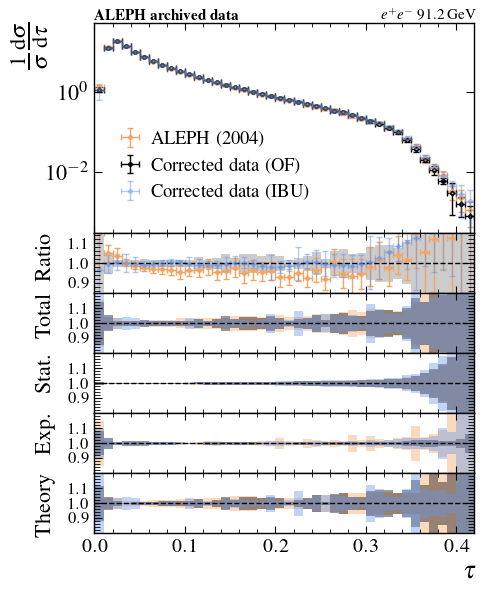

aleph (42,) (42,)
unifold (42,) (42,)


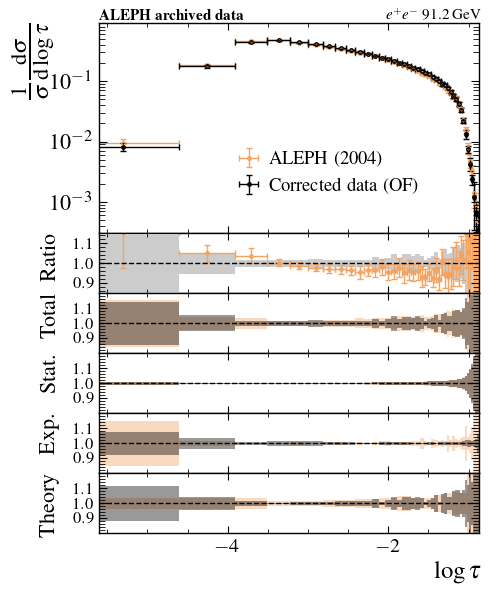

In [46]:
import matplotlib.patches as patches

def plotBand(ax, x, y, syst_err, bin_widths, color, alpha=0.4):
    """
    Plot points with systematic uncertainty:
      * semi-transparent rectangles per bin
      * a continuous symmetric error band y ± syst_err

    Parameters
    ----------
    ax : matplotlib Axes
        Axis to draw on.
    x : array-like
        Bin centers.
    y : array-like
        Values at bin centers.
    syst_err : array-like
        Symmetric systematic uncertainties (same length as x).
    bin_widths : array-like
        Bin widths (same length as x).
    color : str
        Color for markers and boxes/band.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    syst_err = np.asarray(syst_err)
    bin_widths = np.asarray(bin_widths)

    # 1) Draw per-bin systematic boxes
    # for xi, yi, si, wi in zip(x, y, syst_err, bin_widths):
    #     ax.add_patch(plt.Rectangle(
    #         (xi - wi/4, yi - si),  # bottom-left corner
    #         wi/2,                  # width = half the bin width
    #         2*si,                  # total height = ±syst
    #         color=color, alpha=0.3, linewidth=0
    #     ))

    # 2) Add a continuous symmetric error band y ± syst_err
    # ax.fill_between(
    #     x,
    #     y - syst_err,
    #     y + syst_err,
    #     color=color,
    #     alpha=alpha,
    #     step='mid'  # optional: 'mid' makes it align like a histogram
    # )

    for xi, yi, err, bw in zip(x, y, syst_err, bin_widths):
        rect = patches.Rectangle(
            (xi - bw/2, yi - err),   # bottom-left corner
            bw,                      # width
            2 * err,                 # height
            facecolor=color,
            alpha=alpha,
            edgecolor='none'
        )
        ax.add_patch(rect)

# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
}

# configuration
paperPlotConf = {
    "tau" : {
        "ax2_xlim" : [0, 0.42], # lowest aleph bin is 1-0.58 = 0.42
        "ax1_ylim" : [3*10**-4, 5*10**1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$",
        "ax2_xlabel" : r"$\tau$",
        "legend_bbox" : (0, 0.02)
    },
    "logtau" : {
        "ax2_xlim" : [-5.6, math.log(0.42)],
        "ax1_ylim" : [3*10**-4, 9*10**-1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax2_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.3, 0.05)
    }
}

print(aleph["aleph_log_thrust_errs_individual"].shape)

fontsize = 18
for key, region_style in paperPlotConf.items():

    # pick up settings
    binType = "aleph"
    if binType == "aleph":
        bins = conf[key][binType]["bins"]
        bin_centers = conf[key][binType]["x"]
    if binType == "nominal":
        bins = conf[key]["bins"]
        bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = bins[1:] - bins[:-1]

    fig, axs = plt.subplots(
        6, 1,
        sharex=True,
        gridspec_kw={'height_ratios': [3.5, 1, 1, 1, 1, 1]},  # top panel taller, bottom three equal
        figsize=style["figsize"]
    )
    plt.subplots_adjust(hspace=0)


    # inPlots
    inPlots = {}
    inPlots["aleph"] = {
        "plotType": "errorbar", 
        "x": conf[key]["aleph"]["x"], "y": conf[key]["aleph"]["y"], 
        "xerr":conf[key]["aleph"]["xerr"], "yerr":conf[key]["aleph"]["yerr"],
        "color": "sandybrown", 
        "label": 'ALEPH (2004)', 
        "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2,
        "skipratio" : True if binType == "nominal" else False
    }
    # unfolded result
    inPlots["unifold"] = {
        "plotType": "errorbar", 
        "x": bin_centers, "y": plots[key][f"unifold_{binType}_ensemble0"][0], 
        "xerr":bin_widths/2, "yerr":errors[key][f"unifold_{binType}_ensemble0"]["total"],
        "color": "black", #"cornflowerblue", 
        "label": "Corrected data (OF)", 
        "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2,
    }

    # calculate agreement
    if key == "tau":
        chi2, ndf, chi2_div_ndf, p_value = chi2_ndf(
            y1 = inPlots["aleph"]["y"], yerr1 = inPlots["aleph"]["yerr"], 
            y2 = inPlots["unifold"]["y"], yerr2 = inPlots["unifold"]["yerr"]
        )
        print(f"ALEPH vs OF Chi2, ndf, chi2/ndf, p-value: {chi2:.3f}, {ndf}, {chi2_div_ndf:.3f}, {p_value:.8f}")

        rms, pulls = pull_rms(
            y1 = inPlots["aleph"]["y"], yerr1 = inPlots["aleph"]["yerr"], 
            y2 = inPlots["unifold"]["y"], yerr2 = inPlots["unifold"]["yerr"]
        )
        print(f"            RMS: {rms:.5f}")

        mean_shift, shift_sigma, Z = global_shift(
            y1 = inPlots["aleph"]["y"], yerr1 = inPlots["aleph"]["yerr"], 
            y2 = inPlots["unifold"]["y"], yerr2 = inPlots["unifold"]["yerr"]
        )
        print(f"            Mean Shift, Shift Sigma, Z: {mean_shift:.5f}, {shift_sigma:.5f}, {Z:.5f}")
        
    # ibu result
    if key in ibu_results.keys():
        # ibu currently just for aleph binning
        if bin_centers.shape == ibu_results[key]["nominal"].shape:
            ibu_bin_centers = bin_centers
            ibu_xerr = bin_widths/2
        else:
            ibu_bin_centers = conf[key]["aleph"]["x"]
            ibu_xerr = conf[key]["aleph"]["xerr"]
            
        inPlots["ibu"] = {
            "plotType": "errorbar", 
            "x": ibu_bin_centers, "y": ibu_results[key]["nominal"],
            "xerr":ibu_xerr, "yerr": ibu_results[key]["total_uncert"],
            "color": "cornflowerblue", #"gray", 
            "label": "Corrected data (IBU)", 
            "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2, "alpha" : 0.5,
            "skipratio" : False,
            "ratioDenom" : plots[key][f"unifold_aleph_ensemble0"]
        }

        chi2, ndf, chi2_div_ndf, p_value = chi2_ndf(
            y1 = inPlots["aleph"]["y"], yerr1 = inPlots["aleph"]["yerr"], 
            y2 = inPlots["ibu"]["y"], yerr2 = inPlots["ibu"]["yerr"]
        )
        print(f"ALEPH vs IBU Chi2, ndf, chi2/ndf, p-value: {chi2:.3f}, {ndf}, {chi2_div_ndf:.3f}, {p_value:.8f}")

        chi2, ndf, chi2_div_ndf, p_value = chi2_ndf(
            y1 = inPlots["ibu"]["y"], yerr1 = inPlots["ibu"]["yerr"], 
            y2 = inPlots["unifold"]["y"], yerr2 = inPlots["unifold"]["yerr"]
        )
        print(f"IBU vs OF Chi2, ndf, chi2/ndf, p-value: {chi2:.3f}, {ndf}, {chi2_div_ndf:.3f}, {p_value:.8f}")

        # inPlots["ibu_iter1"] = {
        #     "plotType": "errorbar", 
        #     "x": bin_centers, "y": ibu_results[key+"_iter1"]["nominal"],
        #     "xerr":bin_widths/2, "yerr": ibu_results[key+"_iter1"]["total_uncert"],
        #     "color": "green", "label": "IBU Iter=1", 
        #     "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2, "alpha" : 0.5
        # }

    # eea delphi result
    if key == "tau" and plotOutDir == "delphiComparison":
        inPlots["delphi_ibu"] = {
                "plotType": "errorbar", 
                "x": eea_delphi_thrust["centers"], "y": eea_delphi_thrust["counts"],
                "xerr":eea_delphi_thrust["binwidths"]/2, "yerr": eea_delphi_thrust["errors"],
                "color": "green", "label": "DELPHI EEA (IBU)", 
                "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2, "alpha" : 0.5,
                "ratioDenom" : plots[key][f"unifold_nominal_ensemble0"]
        }
    
    # ax0 error bar plots
    for _, plot in inPlots.items():
        print(_, plot["x"].shape, plot["y"].shape)
        axs[0].errorbar(
            plot["x"], 
            plot["y"], 
            color = plot["color"], 
            label = plot["label"], 
            xerr = plot["xerr"], 
            yerr = plot["yerr"], 
            fmt=plot.get("fmt", 'o'), 
            lw=plot.get("lw", 2), 
            capsize=plot.get("capsize", 3), 
            capthick=1, 
            markersize=plot.get("markersize", 1.5),
            alpha=plot.get("alpha", 1),
            markerfacecolor=plot.get("markerfacecolor", "auto")
        )

    # handle ax0 specific
    axs[0].legend(
        loc = "lower left", 
        bbox_to_anchor = region_style["legend_bbox"], 
        ncol = 1,
        fontsize = 13.5,
        handletextpad=0.7,
        handlelength=0.8,
        labelspacing=0.5
    )
    axs[0].set_ylabel(region_style["ax1_ylabel"], fontsize=style.get("ax1_ylabel_fs", 18), labelpad=-1)
    axs[0].set_ylim(region_style["ax1_ylim"])
    axs[0].set_yscale("log")
    axs[0].set_ylim(region_style["ax1_ylim"][0], region_style["ax1_ylim"][1])
    axs[0].tick_params(axis='both', which='major', labelsize=style.get("ax1_tick_ls", 15))
    axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    axs[0].text(0.755, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    # axs[0].text(0.1+region_style["legend_bbox"][0], 0.05, r"Errors shown as: 1$\pm\frac{{\sigma}}{{\mu}}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=9)

    # ax1 ratios
    ratio_denom = plots[key][f"unifold_{binType}_ensemble0"]
    for _, plot in inPlots.items():
        if _ == "unifold": 
            continue
        if "skipratio" in plot.keys() and plot["skipratio"]:
            continue
        
        # to handle different denominator
        rdenom = ratio_denom
        if ratio_denom[0].shape != plot["y"].shape and "ratioDenom" in plot.keys():
            rdenom = plot["ratioDenom"]
        
        
        plot["ratio_y"], plot["ratio_yerr"] = ut.ratio_with_uncertainty(plot["y"], rdenom[0], plot["yerr"], rdenom[1])
        axs[1].errorbar(
            plot["x"], 
            plot["ratio_y"], 
            xerr = plot["xerr"], 
            yerr = plot["ratio_yerr"], 
            fmt = plot.get("fmt", 'o'), 
            color = plot["color"],  
            lw=plot.get("lw", 2), 
            capsize=plot.get("capsize", 3), 
            capthick=1, 
            markersize=plot.get("markersize", 1.5),
            alpha=plot.get("alpha", 1)
        )
    # ratio horizontal line
    axs[1].set_ylim(0.85, 1.15)
    axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)

    plotBand(axs[1], inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), inPlots["unifold"]["yerr"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"], alpha=0.2)
    
    # total error band
    axs[2].set_ylim(0.78, 1.22)
    axs[2].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    plotBand(axs[2], inPlots["aleph"]["x"], np.ones(inPlots["aleph"]["x"].shape), inPlots["aleph"]["yerr"]/inPlots["aleph"]["y"], bin_widths, inPlots["aleph"]["color"])
    plotBand(axs[2], inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), inPlots["unifold"]["yerr"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"])
    if key in ibu_results.keys():
        plotBand(axs[2], inPlots["ibu"]["x"], np.ones(inPlots["ibu"]["x"].shape), inPlots["ibu"]["yerr"]/inPlots["ibu"]["y"], bin_widths, inPlots["ibu"]["color"])
    
    # pick up correct aleph errors
    aleph_individual = aleph["aleph_thrust_errs_individual"] if key == "tau" else aleph["aleph_log_thrust_errs_individual"]
    
    # statistical error band
    axs[3].set_ylim(0.78, 1.22)
    axs[3].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    plotBand(axs[3], inPlots["aleph"]["x"], np.ones(inPlots["aleph"]["x"].shape), aleph_individual[:,0]/inPlots["aleph"]["y"], bin_widths, inPlots["aleph"]["color"])
    plotBand(axs[3], inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), errors[key][f"unifold_{binType}_ensemble0"]["total_stat"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"])
    if key in ibu_results.keys():
        plotBand(axs[3], inPlots["ibu"]["x"], np.ones(inPlots["ibu"]["x"].shape), ibu_results[key]["total_stat"]/inPlots["ibu"]["y"], bin_widths, inPlots["ibu"]["color"])

    
    # systematic error band
    axs[4].set_ylim(0.78, 1.22)
    axs[4].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    plotBand(axs[4], inPlots["aleph"]["x"], np.ones(inPlots["aleph"]["x"].shape), aleph_individual[:,1]/inPlots["aleph"]["y"], bin_widths, inPlots["aleph"]["color"])
    plotBand(axs[4], inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), errors[key][f"unifold_{binType}_ensemble0"]["total_syst_no_theory"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"])
    if key in ibu_results.keys():
        plotBand(axs[4], inPlots["ibu"]["x"], np.ones(inPlots["ibu"]["x"].shape), ibu_results[key]["total_exp_syst"]/inPlots["ibu"]["y"], bin_widths, inPlots["ibu"]["color"])
    
    # systematic error band
    axs[5].set_ylim(0.78, 1.22)
    axs[5].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    plotBand(axs[5], inPlots["aleph"]["x"], np.ones(inPlots["aleph"]["x"].shape), aleph_individual[:,2]/inPlots["aleph"]["y"], bin_widths, inPlots["aleph"]["color"])
    plotBand(axs[5], inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), errors[key][f"unifold_{binType}_ensemble0"]["total_theory_error"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"])
    if key in ibu_results.keys():
        plotBand(axs[5], inPlots["ibu"]["x"], np.ones(inPlots["ibu"]["x"].shape), ibu_results[key]["total_th_syst"]/inPlots["ibu"]["y"], bin_widths, inPlots["ibu"]["color"])
    
    # ax1 settings
    for ax, name in zip(axs[1:], ["Ratio", "Total", "Stat.", "Exp.", "Theory"]):
        ax.set_ylabel(name, fontsize=style.get("ax2_ylabel_fs", 18))
        ax.set_xlim(region_style["ax2_xlim"])
    # set final x-axis
    axs[-1].set_xlabel(region_style["ax2_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)

    # handle others    
    for ax in axs[2:]:
        ax.set_ylim(0.8, 1.2)
        ax.set_yticks([0.9, 1.0, 1.1])
        
    # tick length
    for ax in axs:
        ax.tick_params(axis="y", which="major", length=6)
        ax.tick_params(axis="y", which="minor", length=4)
        ax.tick_params(axis="x", which="major", length=5)
        ax.tick_params(axis="x", which="minor", length=3)

    # tick size
    axs[0].tick_params(axis='y', labelsize=16)
    for ax in axs[1:]:
        ax.tick_params(axis='y', labelsize=12)

    # enforce settings and save
    fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
    # fig.subplots_adjust(left=0.22, right=0.94, top=0.95, bottom=0.1)
    fig.subplots_adjust(left=0.18, right=0.94, top=0.95, bottom=0.1)
    
    
    outFileName = f"{plotOutDir}/{key}_multipanel.pdf"
    if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
    plt.savefig(outFileName, bbox_inches=None, dpi=150)

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea.pdf"), # output file name
        scale=0.06, tx=272, ty=352,
        logo_fpath='./ee-logo.pdf',
    )

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
        scale=0.06, tx=272, ty=352,
        logo_fpath='./ee-logo-transparent.pdf',
    )
    
    plt.show()
    plt.close()


In [47]:
# labels for individual components
expLabels = {
    "Ensemble" : "Ensemble",
    "NTPC" : "NTPC",
    "Track pT": r"Track p$_{\mathrm{T}}$",
    "Charged Energy" : "Charged Energy",
    "Thrust w/o Neutrals" : "Nuetrals Excluded",
    "Thrust w/ MissP" : r"Include $\vec{p}_{\mathrm{MET}}$",
    # "nes_up": "NES Up 5\%",
    # "nes_down": "NES Down 5\%",
    "nes": "NES $\pm$ 5\%",
    "ner": "NEE", #R p=2.5\%",
    
}
theoryLabels = {
    "Pythia8" : r"$\textsc{Pythia}$ 8.230",
    "Pythia8_nh" : r"$\textsc{Pythia}$ Had. Off",
    "Herwig" : r"$\textsc{Herwig}$ 7.1.5", 
    "Sherpa" : r"$\textsc{Sherpa}$ 2.2.6",
}

logtau nominal
(96,) (96,)
(96,) (96,)
(96,) (96,)
(96,) (96,)


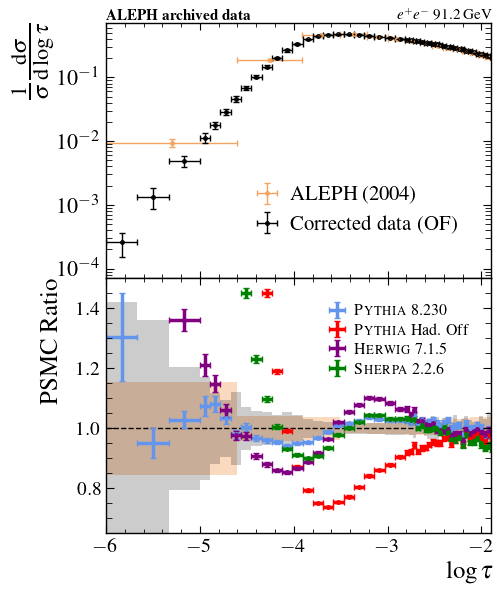

logtau aleph
(42,) (42,)
(42,) (42,)
(42,) (42,)
(42,) (42,)


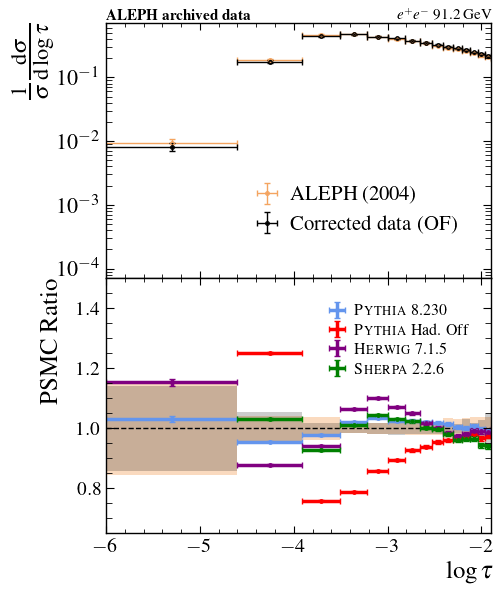

logtau nominal
(96,) (96,)
(96,) (96,)
(96,) (96,)
(96,) (96,)


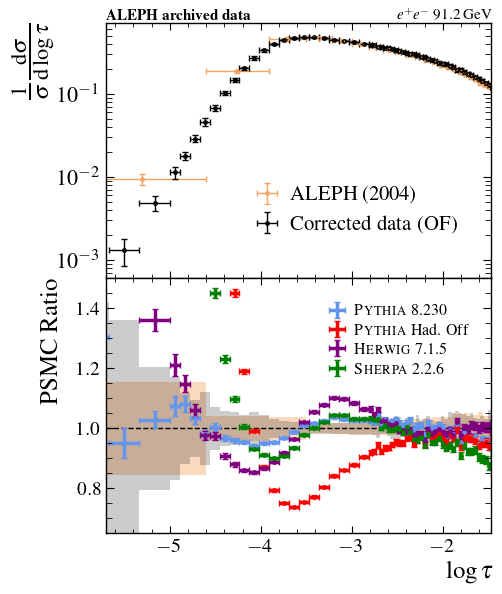

logtau nominal
(96,) (96,)
(96,) (96,)
(96,) (96,)
(96,) (96,)


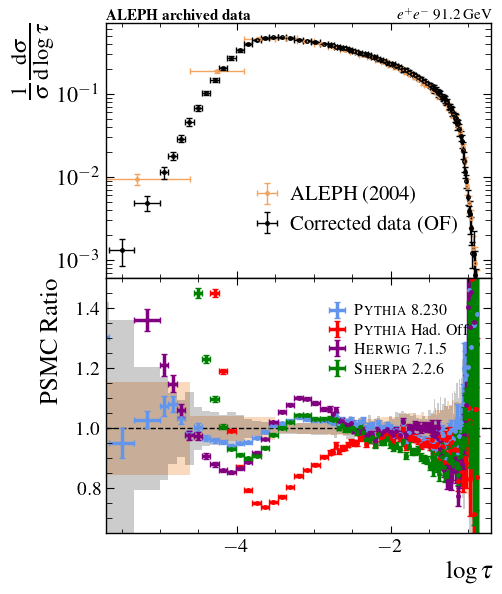

In [55]:
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    # "font.family": "STIXGeneral",
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
}

# configuration
paperPlotConf = {
    "peak_nominal" : {
        "key" : "logtau",
        "ax2_xlim" : [-6, math.log(0.15)],
        "ax1_ylim" : [7*10**-5, 7*10**-1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax2_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.315, 0.05),  
        "binType" : "nominal",
    },
    "peak_aleph" : {
        "key" : "logtau",
        "ax2_xlim" : [-6, math.log(0.15)],
        "ax1_ylim" : [7*10**-5, 7*10**-1], #[6*10**-4, 7*10**-1]
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax2_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.315, 0.05),  
        "binType" : "aleph",
    },
    "peak+tail_nominal" : {
        "key" : "logtau",
        "ax2_xlim" : [-5.7, math.log(0.23)],
        "ax1_ylim" : [6*10**-4, 7*10**-1], #[2*10**-3, 7*10**-1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax2_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.315, 0.05),
        "binType" : "nominal",
    },
    "full_nominal" : {
        "key" : "logtau",
        "ax2_xlim" : [-5.7, math.log(0.5)],
        "ax1_ylim" : [6*10**-4, 7*10**-1], #[2*10**-3, 7*10**-1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax2_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.315, 0.05),
        "binType" : "nominal",
    },
    # "tail" : {
    #     "key" : "tau",
    #     "ax2_xlim" : [0.05, 0.16],
    #     "ax1_ylim" : [0, 8],
    #     "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$",
    #     "ax2_xlabel" : r"$\tau$",
    #     "legend_bbox" : (0.22, 0.52),
    #     "legend_fs" : 9,
    #     "ax1_yscale": "linear",
    # }
}

fontsize = 18
for region, region_style in paperPlotConf.items():

    # pick up settings
    key = region_style["key"]
    # binType = "nominal"
    # bins = conf[key]["bins"]
    # bin_widths = bins[1:] - bins[:-1]
    # bin_centers = (bins[:-1] + bins[1:]) / 2
    
    binType = region_style["binType"]
    if binType == "aleph":
        bins = conf[key][binType]["bins"]
        bin_centers = conf[key][binType]["x"]
    if binType == "nominal":
        bins = conf[key]["bins"]
        bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = bins[1:] - bins[:-1]
    print(key, binType)

    fig,axs = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1]},  # top panel taller, bottom three equal
        figsize=style["figsize"]
    )
    plt.subplots_adjust(hspace=0)


    # inPlots
    inPlots = {}
    inPlots["aleph"] = {
        "plotType": "errorbar", 
        "x": conf[key]["aleph"]["x"], "y": conf[key]["aleph"]["y"], 
        "xerr":conf[key]["aleph"]["xerr"], "yerr":conf[key]["aleph"]["yerr"],
        "color": "sandybrown", "label": 'ALEPH (2004)', 
        "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2,
    }
    # unfolded result
    inPlots["unifold"] = {
        "plotType": "errorbar", 
        "x": bin_centers, "y": plots[key][f"unifold_{binType}_ensemble0"][0], 
        "xerr":bin_widths/2, "yerr":errors[key][f"unifold_{binType}_ensemble0"]["total"],
        "color": "black", #"cornflowerblue", 
        "label": "Corrected data (OF)", 
        "fmt" : "o", "markersize": 2.5, "markerfacecolor" : "none", "lw" : 1, "capsize" : 2,
    }
    # theory comparison plots
    # PYTHIA8_MC_TGenBefore_NoISR, PYTHIA8_MC_TGenBefore_NoISR_NoHadronization, PYTHIA8_MC_TGenBefore_NoISR_AlphaSmZ_0p1136, PYTHIA8_MC_TGenBefore_NoISR_AlphaSmZ_0p1180
    # inPlots["Pythia8"] = {
    #     "plotType": "stairs", 
    #     "x": bin_centers, "y": plots[key][f"Pythia8_{binType}"][0], 
    #     "xerr":bin_widths/2, "yerr" : plots[key][f"Pythia8_{binType}"][1],
    #     "color": "gray", "label": theoryLabels["Pythia8"], #"Pythia 8.230", 
    #     "ls":"-", "lw": 2.5
    # }
    inPlots["Pythia8"] = {
        "plotType": "stairs", 
        "x": bin_centers, "y": plots[key][f"pythia8230_gen_{binType}"][0], 
        "xerr":bin_widths/2, "yerr" : plots[key][f"pythia8230_gen_{binType}"][1],
        "color": "cornflowerblue", #"gray", 
        "label": theoryLabels["Pythia8"], #"Pythia 8.230", 
        "ls":"-", "lw": 2.5
    }
    inPlots["Pythia8_nh"] = {
        "plotType": "stairs", 
        "x": bin_centers, "y": plots[key][f"pythia8230_gen_hadoff_{binType}"][0], 
        "xerr":bin_widths/2, "yerr" : plots[key][f"pythia8230_gen_hadoff_{binType}"][1],
        "color": "red", "label": theoryLabels["Pythia8_nh"], #"Pythia 8.230", 
        "ls":"-", "lw": 2.5
    }
    inPlots["Herwig"] = {
        "plotType": "stairs", 
        "x": bin_centers, "y": plots[key][f"herwig715_{binType}"][0], 
        "xerr":bin_widths/2, "yerr" : plots[key][f"herwig715_{binType}"][1],
        "color": "purple", "label": theoryLabels["Herwig"], #"Herwig 7.1.5", 
        "ls":"-", "lw" : 2.5
    }
    inPlots["Sherpa"] = {
        "plotType": "stairs", 
        "x": bin_centers, "y": plots[key][f"sherpa226_{binType}"][0], 
        "xerr":bin_widths/2, "yerr": plots[key][f"sherpa226_{binType}"][1],
        "color": "green", "label": theoryLabels["Sherpa"], #"Sherpa 2.2.6", 
        "ls":"-", "lw" : 2.5
    }
    
    # ax0 error bar plots
    for _, plot in inPlots.items():
        if _ in ["Pythia8", "Pythia8_nh", "Herwig", "Sherpa"]: 
            continue
        if plot["plotType"] == "errorbar":
            axs[0].errorbar(
                plot["x"], 
                plot["y"], 
                color = plot["color"], 
                label = plot["label"], 
                xerr = plot["xerr"], 
                yerr = plot["yerr"], 
                fmt=plot.get("fmt", 'o'), 
                lw=plot.get("lw", 2), 
                capsize=plot.get("capsize", 3), 
                capthick=1, 
                markersize=plot.get("markersize", 1.5),
                alpha=plot.get("alpha", 1),
                markerfacecolor=plot.get("markerfacecolor", "auto")
            )
        elif plot["plotType"] == "stairs":
            axs[0].stairs(
                plot["y"], 
                plot["x"], 
                label=plot["label"], 
                color=plot["color"],
                ls=plot["ls"],
                lw=plot.get("lw", 2),
                alpha=plot.get("alpha",1)
            )
        else:
            print("None")

    # theory comparison
    if region == "tail" and key == "tau":
        axs[0].fill_between(tRange, np.array(resummedMinO3_default), np.array(resummedMaxO3_default), color='gray',alpha=0.3)
        axs[0].plot(tRange, resummedAverO3_default, color='gray', label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.31~\\rm{GeV~[global~fit]}$')
        axs[0].plot(tRange, resummedO3_as114O101, color='green', label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$')
        axs[0].plot(tRange, resummedO3_as118O103, color='blue', label='$\\alpha_s(m_Z)=0.1180, ~ \\Omega_1^R=0.31~\\rm{GeV}$')
        
    # handle ax0 specific
    axs[0].legend(
        loc = "lower left", 
        bbox_to_anchor = region_style["legend_bbox"], 
        ncol = 1,
        fontsize = 15, #region_style.get("legend_fs", 13),
        handletextpad=0.7,
        handlelength=0.8, 
        labelspacing=0.5
    )
    axs[0].set_ylabel(region_style["ax1_ylabel"], fontsize=style.get("ax1_ylabel_fs", 18), labelpad=4)
    axs[0].set_ylim(region_style["ax1_ylim"])
    axs[0].set_yscale(region_style.get("ax1_yscale", "log"))
    axs[0].set_ylim(region_style["ax1_ylim"][0], region_style["ax1_ylim"][1])
    axs[0].tick_params(axis='both', which='major', labelsize=style.get("ax1_tick_ls", 15))
    axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    axs[0].text(0.755, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    # axs[0].text(0.1+region_style["legend_bbox"][0], 0.05, r"Errors shown as: 1$\pm\frac{{\sigma}}{{\mu}}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=9)

    ratio_denom = plots[key][f"unifold_{binType}_ensemble0"]
    
    # # ax1 ratio to theory
    # axs[1].set_ylim(0.8, 1.2)
    # axs[1].set_yticks([0.9, 1.0, 1.1])
    # axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    # for _, plot in inPlots.items():
    #     if _ in ["unifold", "aleph", "Pythia8", "Herwig", "Sherpa"]: 
    #         continue
    #     if "yerr" in plot.keys():
    #         plot["ratio_y"], plot["ratio_yerr"] = ut.ratio_with_uncertainty(plot["y"], ratio_denom[0], plot["yerr"], ratio_denom[1])
    #     else:
    #         plot["ratio_y"], _ = ut.ratio_with_uncertainty(plot["y"], ratio_denom[0])

    #     if plot["plotType"] == "errorbar":
    #         axs[1].errorbar(
    #             plot["x"], 
    #             plot["ratio_y"], 
    #             xerr = plot["xerr"], 
    #             yerr = plot["ratio_yerr"], 
    #             fmt = plot.get("fmt", 'o'), 
    #             color = plot["color"],  
    #             lw=plot.get("lw", 2), 
    #             capsize=plot.get("capsize", 3), 
    #             capthick=1, 
    #             markersize=plot.get("markersize", 1.5),
    #             alpha=plot.get("alpha", 1)
    #         )
    #     elif plot["plotType"] == "stairs":
    #         axs[1].plot(
    #             (plot["x"][:-1] + plot["x"][1:]) / 2, 
    #             plot["ratio_y"], 
    #             color = plot["color"],
    #             ls = plot["ls"],
    #             lw = plot.get("lw", 2)
    #         )
    # # theory comparison
    # if region == "tail" and key == "tau":

    #     # nominal with uncertainty on both theory and exp.
    #     r_y, r_yerr = ut.ratio_with_uncertainty(
    #         resummedAverO3_default, 
    #         inPlots["unifold"]["y"], 
    #         resummedMaxO3_default - resummedAverO3_default, # symmetric error 
    #         inPlots["unifold"]["yerr"]
    #     )
    #     axs[1].errorbar(
    #         tRange, 
    #         r_y, 
    #         xerr = inPlots["unifold"]["xerr"],
    #         yerr = r_yerr, 
    #         color='gray', 
    #         label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.31~\\rm{GeV~[global~fit]}$',
    #         lw=2,
    #         capsize=2,
    #         fmt="o",
    #         markersize=2.5
    #     )
        
    #     # omega variation
    #     r_y, r_yerr = ut.ratio_with_uncertainty(
    #         resummedO3_as114O101, 
    #         inPlots["unifold"]["y"], 
    #         np.zeros(resummedO3_as114O101.shape), 
    #         inPlots["unifold"]["yerr"]
    #     )
    #     axs[1].errorbar(
    #         tRange, 
    #         r_y, 
    #         xerr = inPlots["unifold"]["xerr"],
    #         yerr = r_yerr, 
    #         color='green', 
    #         label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$',
    #         lw=2,
    #         capsize=2,
    #         fmt="o",
    #         markersize=2.5
    #     )
        
    #     # alpha_S variation
    #     r_y, r_yerr = ut.ratio_with_uncertainty(
    #         resummedO3_as118O103, 
    #         inPlots["unifold"]["y"], 
    #         np.zeros(resummedO3_as118O103.shape), 
    #         inPlots["unifold"]["yerr"]
    #     )
    #     axs[1].errorbar(
    #         tRange, 
    #         r_y, 
    #         xerr = inPlots["unifold"]["xerr"],
    #         yerr = r_yerr, 
    #         color='blue', 
    #         label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$',
    #         lw=2,
    #         capsize=2,
    #         fmt="o",
    #         markersize=2.5
    #     )
        
       
    # ax2 ratio to MC
    ax = axs[1]
    ax.set_ylim(0.65, 1.5)
    # ax.set_ylim(0.8, 1.2)
    # ax.set_yticks([0.9, 1.0, 1.1])
    ax.axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
    for name in ["Pythia8", "Pythia8_nh", "Herwig", "Sherpa"]:
        plot = inPlots[name]
        # plot["ratio_y"], _ = ut.ratio_with_uncertainty(plot["y"], ratio_denom[0])
        # axs[2].plot(
        #     (plot["x"][:-1] + plot["x"][1:]) / 2, 
        #     plot["ratio_y"], 
        #     color = plot["color"],
        #     ls = plot["ls"],
        #     lw = plot.get("lw", 2),
        #     label=plot["label"]
        # )

        plot["ratio_y"], plot["ratio_yerr"] = ut.ratio_with_uncertainty(
            plot["y"], 
            ratio_denom[0], 
            plot["yerr"], # symmetric error 
            ratio_denom[1]
        )
        print(plot["x"].shape, plot["ratio_y"].shape)
        ax.errorbar(
            plot["x"], 
            plot["ratio_y"], 
            xerr = plot["xerr"], 
            yerr = plot["ratio_yerr"], 
            fmt = plot.get("fmt", 'o'), 
            color = plot["color"],  
            lw=plot.get("lw", 2), 
            capsize=plot.get("capsize", 2), 
            capthick=1, 
            markersize=plot.get("markersize", 2.5),
            alpha=plot.get("alpha", 1),
            label=plot["label"]
        )

    # f _ in ["unifold", "aleph", "Pythia8", "Herwig", "Sherpa"]: 
    # plot = inPlots["unifold"]
    # plot["ratio_y"], plot["ratio_yerr"] = ut.ratio_with_uncertainty(plot["y"], ratio_denom[0], plot["yerr"], ratio_denom[1])
    plotBand(ax, inPlots["aleph"]["x"], np.ones(inPlots["aleph"]["x"].shape), inPlots["aleph"]["yerr"]/inPlots["aleph"]["y"], inPlots["aleph"]["xerr"]*2, inPlots["aleph"]["color"])
    plotBand(ax, inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), inPlots["unifold"]["yerr"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"], alpha=0.2)
    # ax.errorbar(
    #     plot["x"], 
    #     plot["ratio_y"], 
    #     xerr = plot["xerr"], 
    #     yerr = plot["ratio_yerr"], 
    #     fmt = plot.get("fmt", 'o'), 
    #     color = plot["color"],  
    #     lw=plot.get("lw", 2), 
    #     capsize=plot.get("capsize", 3), 
    #     capthick=1, 
    #     markersize=plot.get("markersize", 1.5),
    #     alpha=plot.get("alpha", 1)
    # )
        
    ax.legend(
        loc = "lower left", 
        bbox_to_anchor = (0.52,0.52), #(-0.02,-0.05), 
        ncol = 1,
        fontsize = 11.5,
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=0.6
    )


    # ax1 settings
    for ax, name in zip(axs[1:], ["PSMC Ratio"]): # ["Ratio to\nTheory", "Ratio to\nPSMC"]
        ax.set_ylabel(name, fontsize=region_style.get("ax2_ylabel_fs", 18))
        ax.set_xlim(region_style["ax2_xlim"])
    
    # set final x-axis
    axs[-1].set_xlabel(region_style["ax2_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)
        
    # tick length
    for ax in axs:
        ax.tick_params(axis="y", which="major", length=6)
        ax.tick_params(axis="y", which="minor", length=4)
        ax.tick_params(axis="x", which="major", length=5)
        ax.tick_params(axis="x", which="minor", length=3)

    # tick size
    axs[0].tick_params(axis='y', labelsize=16)
    for ax in axs[1:]:
        ax.tick_params(axis='y', labelsize=14)

    # enforce settings and save
    fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
    # fig.subplots_adjust(left=0.22, right=0.94, top=0.95, bottom=0.1)
    fig.subplots_adjust(left=0.20, right=0.97, top=0.95, bottom=0.1)
    
    
    outFileName = f"{plotOutDir}/{key}_{region}_mcComparison.pdf"
    if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
    plt.savefig(outFileName, bbox_inches=None, dpi=150)
    
    
    plt.show()
    plt.close()

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea.pdf"), # output file name
        scale=0.06, tx=85, ty=352,
        logo_fpath='./ee-logo.pdf',
    )

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
        scale=0.06, tx=85, ty=352,
        logo_fpath='./ee-logo-transparent.pdf',
    )


[2.49222340e-01 2.18011829e-01 1.92841362e-01 1.70833341e-01
 1.51559919e-01 1.34783028e-01 1.20685792e-01 1.08130838e-01
 9.72880218e-02 8.79378865e-02 7.98086716e-02 7.26798256e-02
 6.64326421e-02 6.09810519e-02 5.61998475e-02 5.20023208e-02
 4.82854819e-02 4.49439306e-02 4.19440397e-02 3.92716419e-02
 3.68868884e-02 3.47133985e-02 3.26978523e-02 3.08258590e-02
 2.90897200e-02 2.74812513e-02 2.60114394e-02 2.46603967e-02
 2.34136372e-02 2.22417356e-02 2.11313735e-02 2.01218022e-02
 1.92092104e-02 1.83751085e-02 1.76002821e-02 1.68525496e-02
 1.61162109e-02 1.54403497e-02 1.48053359e-02 1.42111334e-02
 1.36506654e-02 1.31560970e-02 1.27266849e-02 1.23286191e-02
 1.19631513e-02 1.15815102e-02 1.11860777e-02 1.08332849e-02
 1.05433714e-02 1.02851094e-02 1.00294970e-02 9.79939422e-03
 9.57820129e-03 9.35537797e-03 9.12389309e-03 8.95985513e-03
 8.80254169e-03 8.66077005e-03 8.55959160e-03 8.46112111e-03
 8.37297529e-03 8.28760403e-03 8.17258010e-03 8.03327023e-03
 7.87981075e-03 7.712560

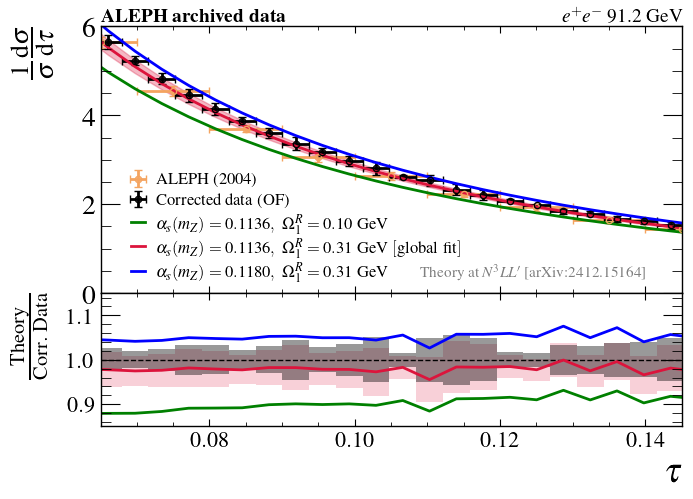

In [56]:
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    # "font.family": "STIXGeneral",
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 25,
    "ax2_xlabel_fs" : 25,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (7,5), #(8, 8/1.618033988749895), 
    "header_fontsize" : 14,
}

# configuration
paperPlotConf = {
    "tail" : {
        "key" : "tau",
        "ax2_xlim" : [0.065, 0.145],
        "ax1_ylim" : [0, 6],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$ ($\frac{1}{\sigma} \frac{\mathrm{d} \sigma^{\mathrm{N^3LL\prime}}}{\mathrm{d} \tau}$)",
        "ax2_xlabel" : r"$\tau$",
        "legend_bbox" : (0.05, 0.15),
        "legend_fs" : 9,
        "ax1_yscale": "linear",
    }
}

fontsize = 18
for region, region_style in paperPlotConf.items():

    # pick up settings
    key = region_style["key"]
    binType = "nominal"
    bins = conf[key]["bins"]
    bin_widths = bins[1:] - bins[:-1]
    bin_centers = (bins[:-1] + bins[1:]) / 2

    fig, axs = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1]},  # top panel taller, bottom three equal
        figsize=style["figsize"]
    )
    plt.subplots_adjust(hspace=0)


    # inPlots
    inPlots = {}
    inPlots["aleph"] = {
        "plotType": "errorbar", 
        "x": conf[key]["aleph"]["x"], "y": conf[key]["aleph"]["y"], 
        "xerr":conf[key]["aleph"]["xerr"], "yerr":conf[key]["aleph"]["yerr"],
        "color": "sandybrown", "label": 'ALEPH (2004)', 
        "fmt" : "o", "markersize": 4.5, 
        "markerfacecolor" : "none", "lw" : 2, "capsize" : 3,
    }
    # unfolded result
    inPlots["unifold"] = {
        "plotType": "errorbar", 
        "x": bin_centers, "y": plots[key][f"unifold_{binType}_ensemble0"][0], 
        "xerr":bin_widths/2, "yerr":errors[key][f"unifold_{binType}_ensemble0"]["total"],
        "color": "black", #"cornflowerblue", 
        "label": "Corrected data (OF)", 
        "fmt" : "o", "markersize": 4.5, 
        "markerfacecolor" : "none", "lw" : 2, "capsize" : 3,
    }

    handles = []
    labels = []
    
    # ax0 error bar plots
    ax = axs[0]
    for _, plot in inPlots.items():
        h = ax.errorbar(
            plot["x"], 
            plot["y"], 
            color = plot["color"], 
            label = plot["label"], 
            xerr = plot["xerr"], 
            yerr = plot["yerr"], 
            fmt=plot.get("fmt", 'o'), 
            lw=plot.get("lw", 2), 
            capsize=plot.get("capsize", 3), 
            capthick=1, 
            markersize=plot.get("markersize", 1.5),
            alpha=plot.get("alpha", 1),
            markerfacecolor=plot.get("markerfacecolor", "auto")
        )
        handles.append(h)
        labels.append(plot["label"])

    # theory comparison
    if region == "tail" and key == "tau":
        ax.fill_between(tRange, np.array(resummedMinO3_default), np.array(resummedMaxO3_default), color='crimson',alpha=0.3)

        # Hyperlinked text part -> Couldn't figure out how to make the arxiv link clickable but would be great
        # from matplotlib.text import Text
        # arxiv_link = Text(
        #     0.5, 1.02,   # position (relative to axes coordinates if you want)
        #     "[2412.15164]",
        #     url="https://arxiv.org/abs/2412.15164",
        #     transform=ax.transAxes,
        #     ha="center"
        # )

        tList = [
            [resummedO3_as114O101, "green", '$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$'], # https://arxiv.org/abs/2412.15164
            [resummedAverO3_default, "crimson", '$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.31~\\rm{GeV~[global~fit]}$'],
            [resummedO3_as118O103, "blue", '$\\alpha_s(m_Z)=0.1180, ~ \\Omega_1^R=0.31~\\rm{GeV}$']
        ]
        
        for tY, color, label in tList:
            h, = ax.plot(tRange, tY, color=color, label=label) #, alpha=0.5)
            handles.append(h)
            labels.append(label)
            
    
    # handle ax0 specific
    ax.legend(
        handles,
        labels,
        loc = "lower left", 
        bbox_to_anchor = (0.01, -0.05), 
        ncol = 1,
        fontsize = 12,
        handletextpad=0.7,
        handlelength=0.8, 
    )

    # labels
    # ylabel = r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$ ($\frac{1}{\sigma} \frac{\mathrm{d} \sigma^{\mathrm{N^3LL\prime}}}{\mathrm{d} \tau}$)", 
    ylabel = r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$"
    
    ax.set_ylabel(
        ylabel,
        fontsize=25, 
        labelpad=20
    )
    ax.set_xlabel(r"$\tau$", fontsize=25, labelpad=5)
    
    # scale and limits
    ax.set_yscale("linear")
    ax.set_ylim(0, 6)
    # ax.set_xlim(0.062, 0.145)
    ax.set_xlim(0.065, 0.145)
    
    # ticks
    ax.minorticks_on()
    ax.tick_params(axis='both', labelsize=20)

    # header
    ax.text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=ax.transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    ax.text(0.795, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=ax.transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    # ax.text(0.55, 0.05, r"Theory at $N^3LL^{\prime}$ [arXiv:2412.15164]", transform=ax.transAxes, ha='left', va='bottom', fontsize=11, color="gray")
    ax.annotate(
        r"Theory at $N^3LL^{\prime}$ [arXiv:2412.15164]",
        xy=(0.55, 0.05), xycoords='axes fraction',
        ha='left', va='bottom',
        fontsize=11, color="gray",
        url="https://arxiv.org/abs/2412.15164"
    )
    
    # ax1 ratio to theory
    ax = axs[1]

    # nominal with uncertainty on both theory and exp.
    r_y, r_yerr = ut.ratio_with_uncertainty(
        resummedAverO3_default, 
        inPlots["unifold"]["y"], 
        resummedMaxO3_default - resummedAverO3_default, # symmetric error 
        inPlots["unifold"]["yerr"]
    )
    ax.errorbar(
        tRange, 
        r_y, 
        xerr = None, #inPlots["unifold"]["xerr"],
        yerr = None, #r_yerr, 
        color='crimson', 
        label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.31~\\rm{GeV~[global~fit]}$',
        lw=2,
        capsize=2,
        fmt="-", #"o",
        markersize=2.5
    )
    print(resummedMaxO3_default - resummedAverO3_default)
    plotBand(ax, tRange, r_y, r_yerr, bin_widths, "crimson", alpha=0.2)
    
    # omega variation
    r_y, r_yerr = ut.ratio_with_uncertainty(
        resummedO3_as114O101, 
        inPlots["unifold"]["y"], 
        np.zeros(resummedO3_as114O101.shape), 
        inPlots["unifold"]["yerr"]
    )
    ax.errorbar(
        tRange, 
        r_y, 
        xerr = None, #inPlots["unifold"]["xerr"],
        yerr = None, #r_yerr, 
        color='green', 
        label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$',
        lw=2,
        capsize=2,
        fmt="-", #"o",
        markersize=2.5
    )
    
    # alpha_S variation
    r_y, r_yerr = ut.ratio_with_uncertainty(
        resummedO3_as118O103, 
        inPlots["unifold"]["y"], 
        np.zeros(resummedO3_as118O103.shape), 
        inPlots["unifold"]["yerr"]
    )
    ax.errorbar(
        tRange, 
        r_y, 
        xerr = None, #inPlots["unifold"]["xerr"],
        yerr = None, #r_yerr, 
        color='blue', 
        label='$\\alpha_s(m_Z)=0.1136, ~ \\Omega_1^R=0.10~\\rm{GeV}$',
        lw=2,
        capsize=2,
        fmt="-", #"o",
        markersize=2.5
    )

    # uncertainty bands
    plotBand(ax, inPlots["unifold"]["x"], np.ones(inPlots["unifold"]["x"].shape), inPlots["unifold"]["yerr"]/inPlots["unifold"]["y"], bin_widths, inPlots["unifold"]["color"])
    

    # settings
    ax.set_ylim(0.85, 1.15)
    ax.set_yticks([0.9, 1.0, 1.1])
    ax.axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)

    ax.set_ylabel(r"$\frac{\rm Theory}{\rm Corr.\; Data}$", fontsize=20, labelpad=15)
    ax.set_xlabel(r"$\tau$", fontsize=25, labelpad=5)
    
    # ticks
    ax.minorticks_on()
    ax.tick_params(axis='both', labelsize=16)

    # logo
    # _ = eeaLogo(axs[0], coords=(0.9, 0.8), zoom=0.065, eea_logo_path = "./ee-logo.png")
    # eeaLogo(
    #     ax,
    #     coords=(0.9, 0.8),        # (x,y) coords in axis fraction space
    #     eea_logo_path="./ee-logo.pdf",
    #     zoom=0.08,
    #     dpi=600
    # )
    
    # enforce settings and save
    fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
    fig.subplots_adjust(left=0.15, right=0.98, top=0.95, bottom=0.15)
    
    
    outFileName = f"{plotOutDir}/{key}_{region}_theoryComparison_WithRatio.pdf"
    if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
    plt.savefig(outFileName, bbox_inches=None, dpi=150)
    # plt.savefig(f"{plotOutDir}/{key}_{region}_theoryComparison_noRatio.pdf", bbox_inches='tight')
    
    plt.show()
    plt.close()

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
        scale=0.075, tx=410, ty=270,
        logo_fpath='./ee-logo-transparent.pdf',
    )

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea.pdf"), # output file name
        scale=0.075, tx=410, ty=270,
        logo_fpath='./ee-logo.pdf',
    )

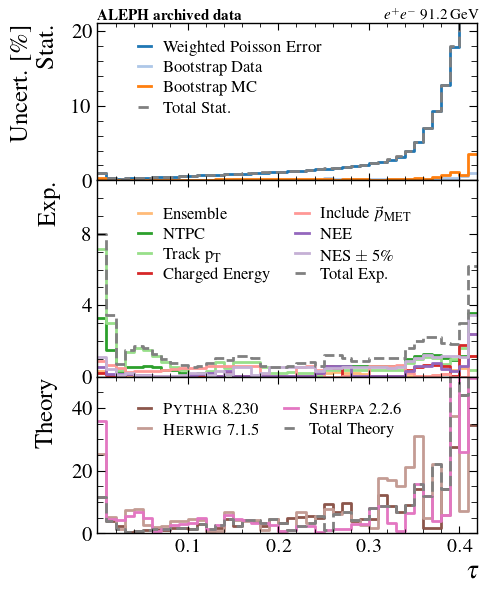

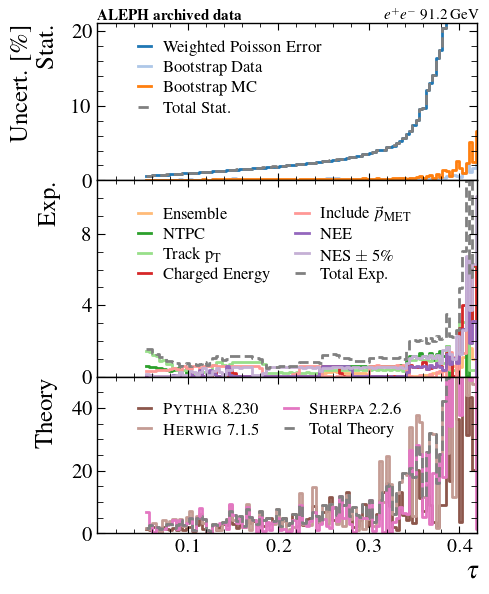

In [61]:
import itertools

def plotArange(z, doThis=False):
    return np.arange(len(z)) if doThis else z

def updateALEPH(A_centers, A_values, B_centers):
    # step 1: build A bin edges (midpoints between centers, plus extrapolated edges)
    A_edges = np.concatenate([
        [A_centers[0] - 0.5*(A_centers[1]-A_centers[0])],   # leftmost edge
        0.5*(A_centers[1:] + A_centers[:-1]),               # midpoints
        [A_centers[-1] + 0.5*(A_centers[-1]-A_centers[-2])] # rightmost edge
    ])
    
    # step 2: for each B center, find which A bin it belongs to
    indices = np.digitize(B_centers, A_edges) - 1  # subtract 1 for 0-based
    indices = np.clip(indices, 0, len(A_values)-1)  # keep within valid range
    
    # step 3: assign values
    B_values_from_A = A_values[indices]
    return B_values_from_A

def extend_y(temp):
    return np.append(temp, temp[-1])
    
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
}

# configuration
paperPlotConf = {
    "tau_aleph" : {
        "key" : "tau",
        "bintype" : "aleph",
        "ax1_xlim" : [0, 0.42],
        "ax1_ylim" : [2*10**-3, 7*10**-1],
        "ax1_ylabel" : "Uncertainty [$\%$]",
        "ax1_xlabel" : r"$\tau$",
        "legend_bbox" : (0.45, 0.05),   
    },
    "tau_nominal" : {
        "key" : "tau",
        "bintype" : "nominal",
        "ax1_xlim" : [0, 0.42],
        "ax1_ylim" : [2*10**-3, 7*10**-1],
        "ax1_ylabel" : "Uncertainty [$\%$]",
        "ax1_xlabel" : r"$\tau$",
        "legend_bbox" : (0.45, 0.05),   
    },
}

fontsize = 18
legendfontsize = 12

plotTotal = True
plotTheoryOnly = False
plotIndividual = True
plotALEPH = True
plotStatExpTheoryTotal = False
colors = plt.cm.tab20.colors  # 20 unique colors
divide = True

for pName, region_style in paperPlotConf.items():

    # setting
    key = region_style["key"]
    binType = region_style["bintype"]
    pname = f"unifold_{binType}_ensemble0"
    nominal = plots[key][pname]
    bins = conf[key]["aleph"]["bins"] if "aleph" in pname else conf[key]["bins"] 
    bin_centers = (bins[:-1] + bins[1:]) / 2
    color_cycle = itertools.cycle(colors)

    # plotting
    fig, axs = plt.subplots(
        3, 1,
        sharex=True,
        gridspec_kw={'height_ratios': [1,1.25,1]},  # top panel taller, bottom three equal
        figsize=style["figsize"]
    )
    plt.subplots_adjust(hspace=0)

    # header
    axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    axs[0].text(0.755, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    
    # individual error breach down
    individual = np.abs(errors[key][pname]["individual"])

    # statistical
    ax = axs[0]
    ax.set_ylim(0, 21)
    for i, label in enumerate(individualErrorLabelOrder):
        if label in ['Stat. (w/o Bootstraps)', 'Bootstrap Data', 'Bootstrap MC']:
            label = "Weighted Poisson Error" if label == 'Stat. (w/o Bootstraps)' else label
            ax.step(bins, extend_y(individual[:, i]/nominal[0]*100), where='post', label=label, color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_stat"]/nominal[0]*100), where='post', label="Total Stat.", color="gray", ls="--")
    
    ax.legend(
        ncol=1, 
        fontsize=legendfontsize,
        bbox_to_anchor=(0.04, 0.25), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=0.6
    )

    # experimental
    ax = axs[1]
    ax.set_ylim(0, 11)
    ax.set_yticks([0,4,8])
    for i, label in enumerate(individualErrorLabelOrder):
        doLabels = ['Ensemble', 'NTPC', 'Track pT', 'Charged Energy', 'Thrust w/o Neutrals', 'Thrust w/ MissP']
        if skipNoNeutrals:
            doLabels = ['Ensemble', 'NTPC', 'Track pT', 'Charged Energy', 'Thrust w/ MissP', 'nes', 'ner']
            
        if label in doLabels:
            ax.step(bins, extend_y(individual[:, i]/nominal[0]*100), where='post', label=expLabels[label], color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_syst_no_theory"]/nominal[0]*100), where='post', label="Total Exp.", color="gray", ls="--")
    ax.legend(
        ncol=2, 
        fontsize=legendfontsize,
        bbox_to_anchor=(0.04, 0.35), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=1.5
    )
    
    # theory
    ax = axs[2]
    ax.set_ylim(0, 50)
    ax.set_yticks([0,20,40])
    theory_errors = np.abs(errors[key][pname]["theory_errors"])
    for i, label in enumerate(theory_weights_order):
        ax.step(bins, extend_y(theory_errors[:, i]/nominal[0]*100), where='post', label=theoryLabels[label], color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_theory_error"]/nominal[0]*100), where='post', label="Total Theory", color="gray", ls="--")
    
    ax.legend(
        ncol=2, 
        fontsize=legendfontsize, 
        bbox_to_anchor=(0.04, 0.45), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=1.5
     )
    
    
    axs[0].set_xlim(region_style["ax1_xlim"][0], region_style["ax1_xlim"][1])
    if "log" not in pName:
        axs[0].set_xticks([0.1,0.2,0.3,0.4])

    # ax1 settings
    for ax, name in zip(axs, ["Uncert. [$\%$]\nStat.", "Exp.", "Theory"]): # "MC Prior"
        if name == "Exp.":
            ax.set_ylabel(name, fontsize=18, labelpad=16)
        else:
            ax.set_ylabel(name, fontsize=18)
        
    # set final x-axis
    axs[-1].set_xlabel(region_style["ax1_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)
        
    # tick length
    for ax in axs:
        ax.tick_params(axis="y", which="major", length=6)
        ax.tick_params(axis="y", which="minor", length=4)
        ax.tick_params(axis="x", which="major", length=5)
        ax.tick_params(axis="x", which="minor", length=3)

    # tick size
    # axs[0].tick_params(axis='y', labelsize=16)
    for ax in axs:
        ax.tick_params(axis='y', labelsize=15)
        
    

    fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
    fig.subplots_adjust(left=0.18, right=0.94, top=0.95, bottom=0.1)
    
    outFileName = f"{plotOutDir}/{key}_{binType}_uncertainty.pdf"
    if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
    plt.savefig(outFileName, bbox_inches=None, dpi=150)

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea.pdf"), # output file name
        # scale=0.045, tx=223, ty=365,
        scale=0.045, tx=200, ty=345,
        logo_fpath='./ee-logo.pdf',
    )

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
        scale=0.045, tx=223, ty=365,
        logo_fpath='./ee-logo-transparent.pdf',
    )
    
    plt.show()
    plt.close()

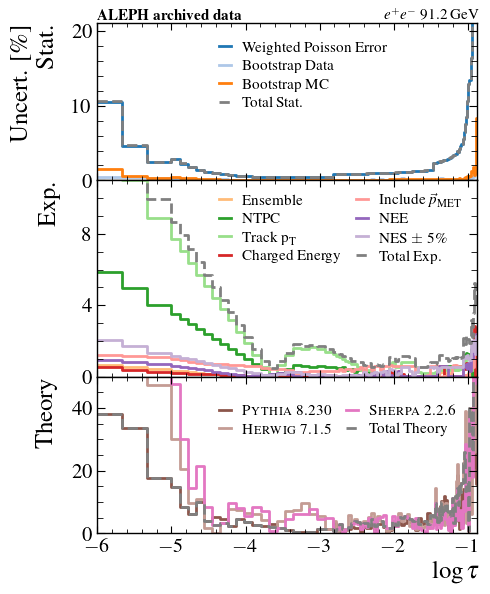

In [60]:
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
}

# configuration
paperPlotConf = {
    "logtau_nominal" : {
        "key" : "logtau",
        "bintype" : "nominal",
        "ax1_xlim" : [-6, math.log(0.42)],
        "ax1_ylim" : [2*10**-3, 7*10**-1],
        "ax1_ylabel" : r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\log{{\tau}}}}$",
        "ax1_xlabel" : r"$\log{{\tau}}$",
        "legend_bbox" : (0.5, 0.05),
    }
}

fontsize = 18
legendfontsize = 11

plotTotal = True
plotTheoryOnly = False
plotIndividual = True
plotALEPH = True
plotStatExpTheoryTotal = False
colors = plt.cm.tab20.colors  # 20 unique colors
divide = True

for pName, region_style in paperPlotConf.items():

    # setting
    key = region_style["key"]
    binType = region_style["bintype"]
    pname = f"unifold_{binType}_ensemble0"
    nominal = plots[key][pname]
    bins = conf[key]["aleph"]["bins"] if "aleph" in pname else conf[key]["bins"] 
    bin_centers = (bins[:-1] + bins[1:]) / 2
    color_cycle = itertools.cycle(colors)
    
    # plotting
    fig, axs = plt.subplots(
        3, 1,
        sharex=True,
        gridspec_kw={'height_ratios': [1,1.25,1]},  # top panel taller, bottom three equal
        figsize=style["figsize"]
    )
    plt.subplots_adjust(hspace=0)
    

    # header
    axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
    axs[0].text(0.755, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])

    # individual error breach down
    individual = np.abs(errors[key][pname]["individual"])

    # statistical
    ax = axs[0]
    ax.set_ylim(0, 21)
    for i, label in enumerate(individualErrorLabelOrder):
        if label in ['Stat. (w/o Bootstraps)', 'Bootstrap Data', 'Bootstrap MC']:
            label = "Weighted Poisson Error" if label == 'Stat. (w/o Bootstraps)' else label
            ax.step(bins, extend_y(individual[:, i]/nominal[0]*100), where='post', label=label, color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_stat"]/nominal[0]*100), where='post', label="Total Stat.", color="gray", ls="--")
    ax.legend(
        ncol=1, 
        fontsize=legendfontsize,
        bbox_to_anchor=(0.26, 0.3), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=0.6
    )

    # experimental
    ax = axs[1]
    ax.set_ylim(0, 11)
    ax.set_yticks([0,4,8])
    for i, label in enumerate(individualErrorLabelOrder):
        
        doLabels = ['Ensemble', 'NTPC', 'Track pT', 'Charged Energy', 'Thrust w/o Neutrals', 'Thrust w/ MissP']
        if skipNoNeutrals:
            doLabels = ['Ensemble', 'NTPC', 'Track pT', 'Charged Energy', 'Thrust w/ MissP', 'nes', 'ner']
            
        if label in doLabels:
            ax.step(bins, extend_y(individual[:, i]/nominal[0]*100), where='post', label=expLabels[label], color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_syst_no_theory"]/nominal[0]*100), where='post', label="Total Exp.", color="gray", ls="--")
    ax.legend(
        ncol=2, 
        fontsize=legendfontsize,
        bbox_to_anchor=(0.26, 0.46), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=1
    )
    
    # theory
    ax = axs[2]
    ax.set_ylim(0, 50)
    ax.set_yticks([0,20,40])
    theory_errors = np.abs(errors[key][pname]["theory_errors"])
    for i, label in enumerate(theory_weights_order):
        ax.step(bins, extend_y(theory_errors[:, i]/nominal[0]*100), where='post', label=theoryLabels[label], color=next(color_cycle), ls="-")
    ax.step(bins, extend_y(errors[key][pname]["total_theory_error"]/nominal[0]*100), where='post', label="Total Theory", color="gray", ls="--")
    
    ax.legend(
        ncol=2, 
        fontsize=legendfontsize, 
        bbox_to_anchor=(0.26, 0.47), 
        loc="lower left",
        handletextpad=0.7,
        handlelength=0.8, 
        columnspacing=1
     )
    
    
    axs[0].set_xlim(region_style["ax1_xlim"][0], region_style["ax1_xlim"][1])
    if "log" not in pName:
        axs[0].set_xticks([0.1,0.2,0.3,0.4])

    # ax1 settings
    for ax, name in zip(axs, ["Uncert. [$\%$]\nStat.", "Exp.", "Theory"]): # "MC Prior"
        if name == "Exp.":
            ax.set_ylabel(name, fontsize=18, labelpad=16)
        else:
            ax.set_ylabel(name, fontsize=18)
        
    # set final x-axis
    axs[-1].set_xlabel(region_style["ax1_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)
        
    # tick length
    for ax in axs:
        ax.tick_params(axis="y", which="major", length=6)
        ax.tick_params(axis="y", which="minor", length=4)
        ax.tick_params(axis="x", which="major", length=5)
        ax.tick_params(axis="x", which="minor", length=3)

    # tick size
    # axs[0].tick_params(axis='y', labelsize=16)
    for ax in axs:
        ax.tick_params(axis='y', labelsize=15)
        
    

    fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
    fig.subplots_adjust(left=0.18, right=0.94, top=0.95, bottom=0.1)
    
    outFileName = f"{plotOutDir}/{key}_{binType}_uncertainty.pdf"
    if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
    plt.savefig(outFileName, bbox_inches=None, dpi=150)

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea.pdf"), # output file name
        # scale=0.045, tx=223, ty=365,
        scale=0.045, tx=250, ty=345, # next to legend
        # scale=0.045, tx=80, ty=365, # upper right
        logo_fpath='./ee-logo.pdf',
    )

    ut.watermark(
        outFileName, # input file name
        outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
        scale=0.045, tx=223, ty=365,
        logo_fpath='./ee-logo-transparent.pdf',
    )
    
    plt.show()
    plt.close()